# Exploratory Data Analysis

**Target:** `TARGET` (1 = client with payment difficulties, 0 = repaid). **Source:** `data/raw/application_train.csv` (307,511 rows × 122 columns).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
FIGURES_DIR = "../reports/figures"

df = pd.read_csv("../data/raw/application_train.csv")
df.shape

(307511, 122)

## 1. Shape & structure

Storage dtype is not the same as measurement scale: many `int64`/`float64` columns are binary flags (`FLAG_*`) or ordinal ratings (`REGION_RATING_CLIENT`), not continuous quantities. Grouping columns by scale rather than dtype is what drives the later scaling/encoding decisions.

In [2]:
df.dtypes.value_counts()

float64    65
int64      41
str        16
Name: count, dtype: int64

In [3]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


**Takeaway:** 122 columns — 65 float, 41 int, and 16 text (string) columns. The text columns are all nominal categoricals; the numeric columns split into true continuous (`AMT_*`, `DAYS_*`, `EXT_SOURCE_*`), binary flags (`FLAG_*`), and a ~47-column block of building statistics (`_AVG`/`_MEDI`/`_MODE`).

## 2. Missing values

Per-column missing rate drives the first feature-reduction decision. Baseline rule: drop columns above 50% missing — overridden per column where a high-missing feature is predictive or its missingness is structural (below).

In [4]:
missing_pct = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct.head(20)

COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
COMMONAREA_MEDI             69.872297
NONLIVINGAPARTMENTS_MEDI    69.432963
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
LIVINGAPARTMENTS_MODE       68.354953
FLOORSMIN_MODE              67.848630
FLOORSMIN_AVG               67.848630
FLOORSMIN_MEDI              67.848630
YEARS_BUILD_AVG             66.497784
YEARS_BUILD_MODE            66.497784
YEARS_BUILD_MEDI            66.497784
OWN_CAR_AGE                 65.990810
LANDAREA_MEDI               59.376738
LANDAREA_AVG                59.376738
LANDAREA_MODE               59.376738
dtype: float64

In [5]:
THRESHOLD = 50
cols_above = missing_pct[missing_pct > THRESHOLD]
print(f"{len(cols_above)} columns above {THRESHOLD}% missing")
cols_above

41 columns above 50% missing


COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
COMMONAREA_MEDI             69.872297
NONLIVINGAPARTMENTS_MEDI    69.432963
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
LIVINGAPARTMENTS_MODE       68.354953
FLOORSMIN_MODE              67.848630
FLOORSMIN_AVG               67.848630
FLOORSMIN_MEDI              67.848630
YEARS_BUILD_AVG             66.497784
YEARS_BUILD_MODE            66.497784
YEARS_BUILD_MEDI            66.497784
OWN_CAR_AGE                 65.990810
LANDAREA_MEDI               59.376738
LANDAREA_AVG                59.376738
LANDAREA_MODE               59.376738
BASEMENTAREA_MODE           58.515956
BASEMENTAREA_MEDI           58.515956
BASEMENTAREA_AVG            58.515956
EXT_SOURCE_1                56.381073
NONLIVINGAREA_MODE          55.179164
NONLIVINGAREA_AVG           55.179164
NONLIVINGARE

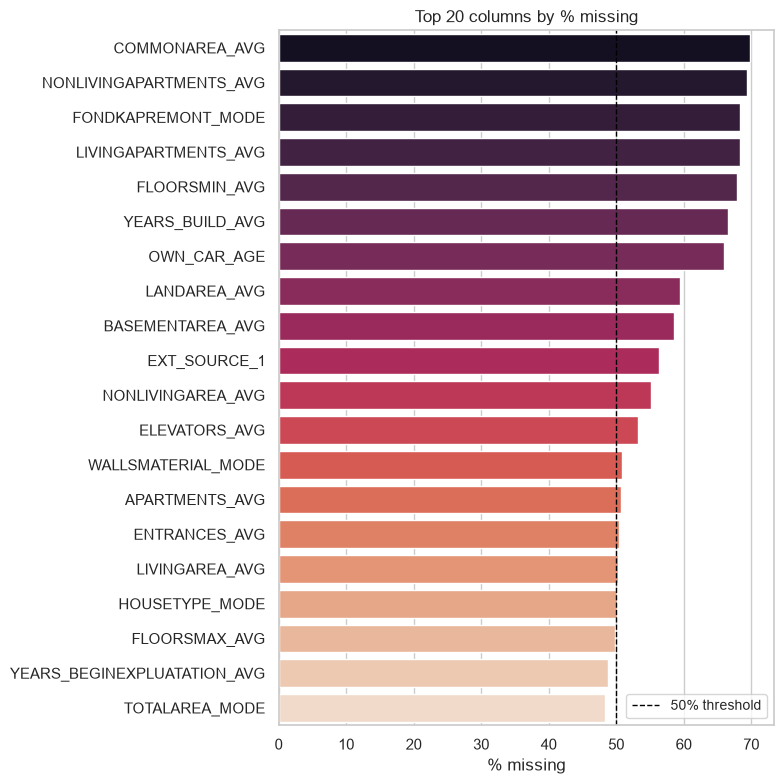

In [6]:
# The building _AVG/_MEDI/_MODE variants share identical missingness; collapse to the _AVG
# representative for a readable plot (keeping metrics that exist only as _MODE).
avg_bases = {c[:-4] for c in missing_pct.index if c.endswith("_AVG")}
redundant = [c for c in missing_pct.index
             if (c.endswith("_MEDI") or c.endswith("_MODE")) and c[:-5] in avg_bases]
missing_pct_plot = missing_pct.drop(redundant)

top = missing_pct_plot.head(20)
fig, ax = plt.subplots(figsize=(8, 8))
sns.barplot(x=top.values, y=top.index, hue=top.index, palette="rocket", legend=False, ax=ax)
ax.axvline(THRESHOLD, color="black", linestyle="--", linewidth=1, label=f"{THRESHOLD}% threshold")
ax.set_xlabel("% missing")
ax.set_ylabel("")
ax.set_title("Top 20 columns by % missing")
ax.legend(loc="lower right", fontsize=10)
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/missing_values_top20.png", dpi=150)
plt.show()

### Structural missingness — not every gap is a data-quality problem

Two high-missing columns are retained despite crossing the threshold:

- **`OWN_CAR_AGE` (66% missing)** — missing precisely when the client owns no car (`FLAG_OWN_CAR == 'N'`), verified below. Not a gap; "not applicable."
- **`EXT_SOURCE_1` (56% missing)** — an external risk score and one of the strongest predictors of `TARGET`; impute rather than drop.

In [7]:
pd.crosstab(df["FLAG_OWN_CAR"], df["OWN_CAR_AGE"].isna(),
            rownames=["FLAG_OWN_CAR"], colnames=["OWN_CAR_AGE missing"])

OWN_CAR_AGE missing,False,True
FLAG_OWN_CAR,,
N,0,202924
Y,104582,5


**Takeaway:** the columns above the 50% threshold are dominated by the building-statistics block. Within that block the `_AVG`/`_MEDI`/`_MODE` variants are identical in missingness and near-perfectly collinear by construction, so preprocessing should keep a single variant per metric regardless of the cutoff. `OWN_CAR_AGE` and `EXT_SOURCE_1` are retained as documented exceptions to the drop rule.